In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

plot_theme <- theme_bw() + theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        strip.text = element_text(size = 14),
        plot.title = element_text(size = 18, hjust = 0.5)
    )

In [2]:

figures_2D_path <- file.path("../figures/IC_patient_comparisons_2D")
figures_3D_path <- file.path("../figures/IC_patient_comparisons_3D")
if (!dir.exists(figures_2D_path)) {
  dir.create(figures_2D_path, recursive = TRUE)
}
if (!dir.exists(figures_3D_path)) {
  dir.create(figures_3D_path, recursive = TRUE)
}

analysis_2D_file_path = file.path(
    "../results/raw_image_quality_metrics/merged_results_2D.parquet"
)
analysis_3D_file_path = file.path(
    "../results/raw_image_quality_metrics/merged_results_3D.parquet"
)
raw_image_2D_quality_metrics <- arrow::read_parquet(analysis_2D_file_path)
raw_image_3D_quality_metrics <- arrow::read_parquet(analysis_3D_file_path)

raw_image_2D_quality_metrics <- as.data.frame(raw_image_2D_quality_metrics)
raw_image_3D_quality_metrics <- as.data.frame(raw_image_3D_quality_metrics)


In [3]:

# make the compartment a factor
raw_image_2D_quality_metrics$compartment <- factor(
    raw_image_2D_quality_metrics$compartment,
    levels = c("organoid", "nuclei", "cell")
)
raw_image_3D_quality_metrics$compartment <- factor(
    raw_image_3D_quality_metrics$compartment,
    levels = c("organoid", "nuclei", "cell")
)
# drop the CQ1 patient
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    filter(!grepl("NF0037_T1_CQ1", patient))
raw_image_3D_quality_metrics <- raw_image_3D_quality_metrics %>%
    filter(!grepl("NF0037_T1_CQ1", patient))
# drop basicpy_status rows
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    filter(basicpy_status != "basicpy")
raw_image_3D_quality_metrics <- raw_image_3D_quality_metrics %>%
    filter(basicpy_status != "basicpy")

head(raw_image_2D_quality_metrics)
head(raw_image_3D_quality_metrics)


,patient,well_fov,channel,z_slice,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit
,<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,NF0014_T1,C10-1,405,0,cell,8.373298,1,0.6454849,raw_image,C10,C,10,C10,Trametinib,1,uM
2,NF0014_T1,C10-1,405,1,cell,8.856489,1,0.7444556,raw_image,C10,C,10,C10,Trametinib,1,uM
3,NF0014_T1,C10-1,405,2,cell,9.540700,1,1.1031303,raw_image,C10,C,10,C10,Trametinib,1,uM
4,NF0014_T1,C10-1,405,3,cell,10.398625,1,1.4968731,raw_image,C10,C,10,C10,Trametinib,1,uM
5,NF0014_T1,C10-1,405,4,cell,11.030758,1,1.7129469,raw_image,C10,C,10,C10,Trametinib,1,uM
6,NF0014_T1,C10-1,405,5,cell,11.481087,1,1.8412120,raw_image,C10,C,10,C10,Trametinib,1,uM


,patient,well_fov,channel,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit
,<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,NF0014_T1,C10-1,405,cell,10.542512,1,1.490372,raw_image,C10,C,10,C10,Trametinib,1,uM
2,NF0014_T1,C10-1,405,nuclei,12.580275,1,1.704747,raw_image,C10,C,10,C10,Trametinib,1,uM
3,NF0014_T1,C10-1,405,organoid,10.542585,1,1.489991,raw_image,C10,C,10,C10,Trametinib,1,uM
4,NF0014_T1,C10-1,488,cell,5.344212,1,1.926199,raw_image,C10,C,10,C10,Trametinib,1,uM
5,NF0014_T1,C10-1,488,nuclei,3.498381,1,1.330744,raw_image,C10,C,10,C10,Trametinib,1,uM
6,NF0014_T1,C10-1,488,organoid,5.350949,1,1.928806,raw_image,C10,C,10,C10,Trametinib,1,uM


## 3D metrics

In [4]:
height_3D <- 12
width_3D <- 12

### Signal to noise ratio

Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 224 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 224 rows containing missing values or values outside the scale range
(`geom_point()`).”


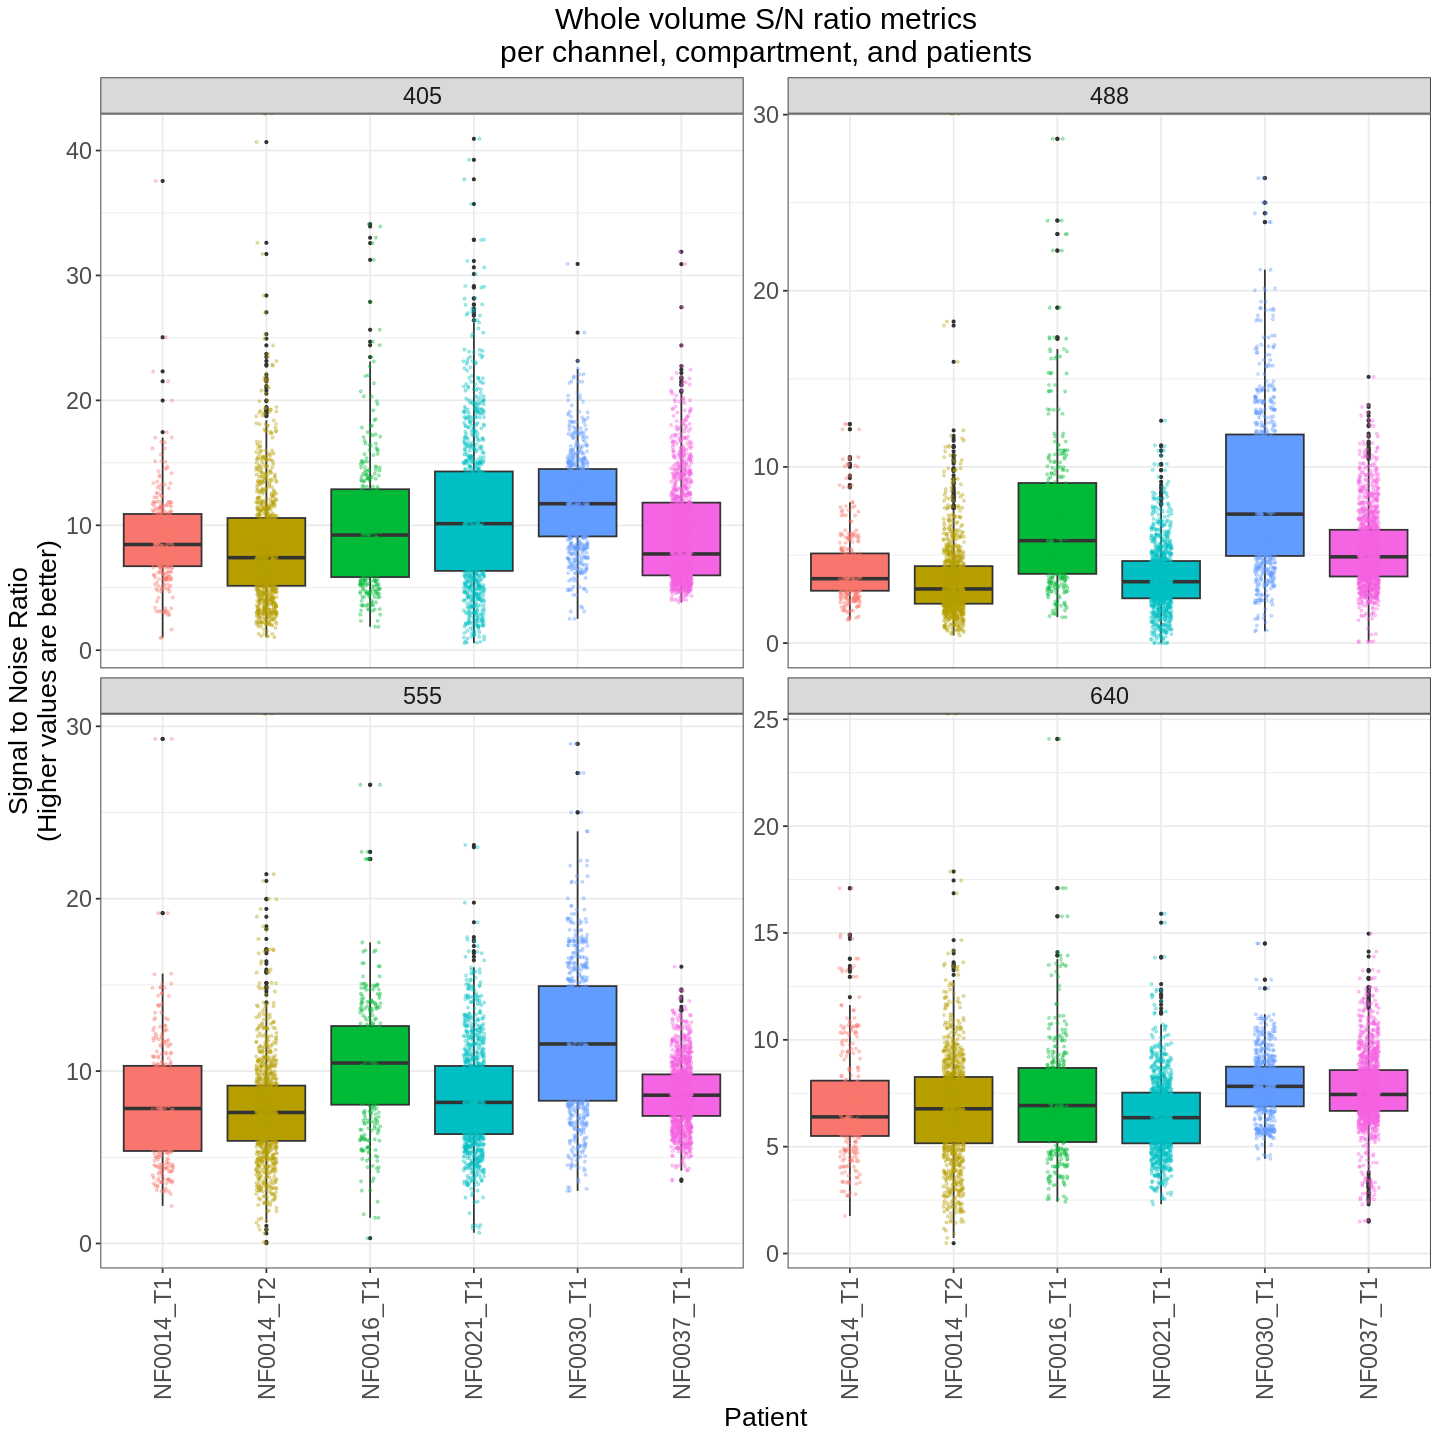

In [5]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
s_n_ratio_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = patient,
            y = signal_to_noise_ratio,
            fill = patient
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = patient
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )
    + labs(
        x = "Patient",
        y = "Signal to Noise Ratio\n(Higher values are better)",
        title = "Whole volume S/N ratio metrics\nper channel, compartment, and patients"
    )
    + facet_wrap(channel~., scales = "free_y")
    + guides(
        fill = guide_legend(
            title = "Patient"
        ),
        color = "none"
    )
    
    + plot_theme
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        legend.position = "none"
    )
)
ggsave(
    filename = file.path(
        figures_3D_path,
        "signal_to_noise_ratio_by_microscope_and_channel_3D.png"
    ),
    plot = s_n_ratio_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
s_n_ratio_plot



### Michelson contrast

Warning message:
“Removed 240 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 240 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 240 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 240 rows containing missing values or values outside the scale range
(`geom_point()`).”


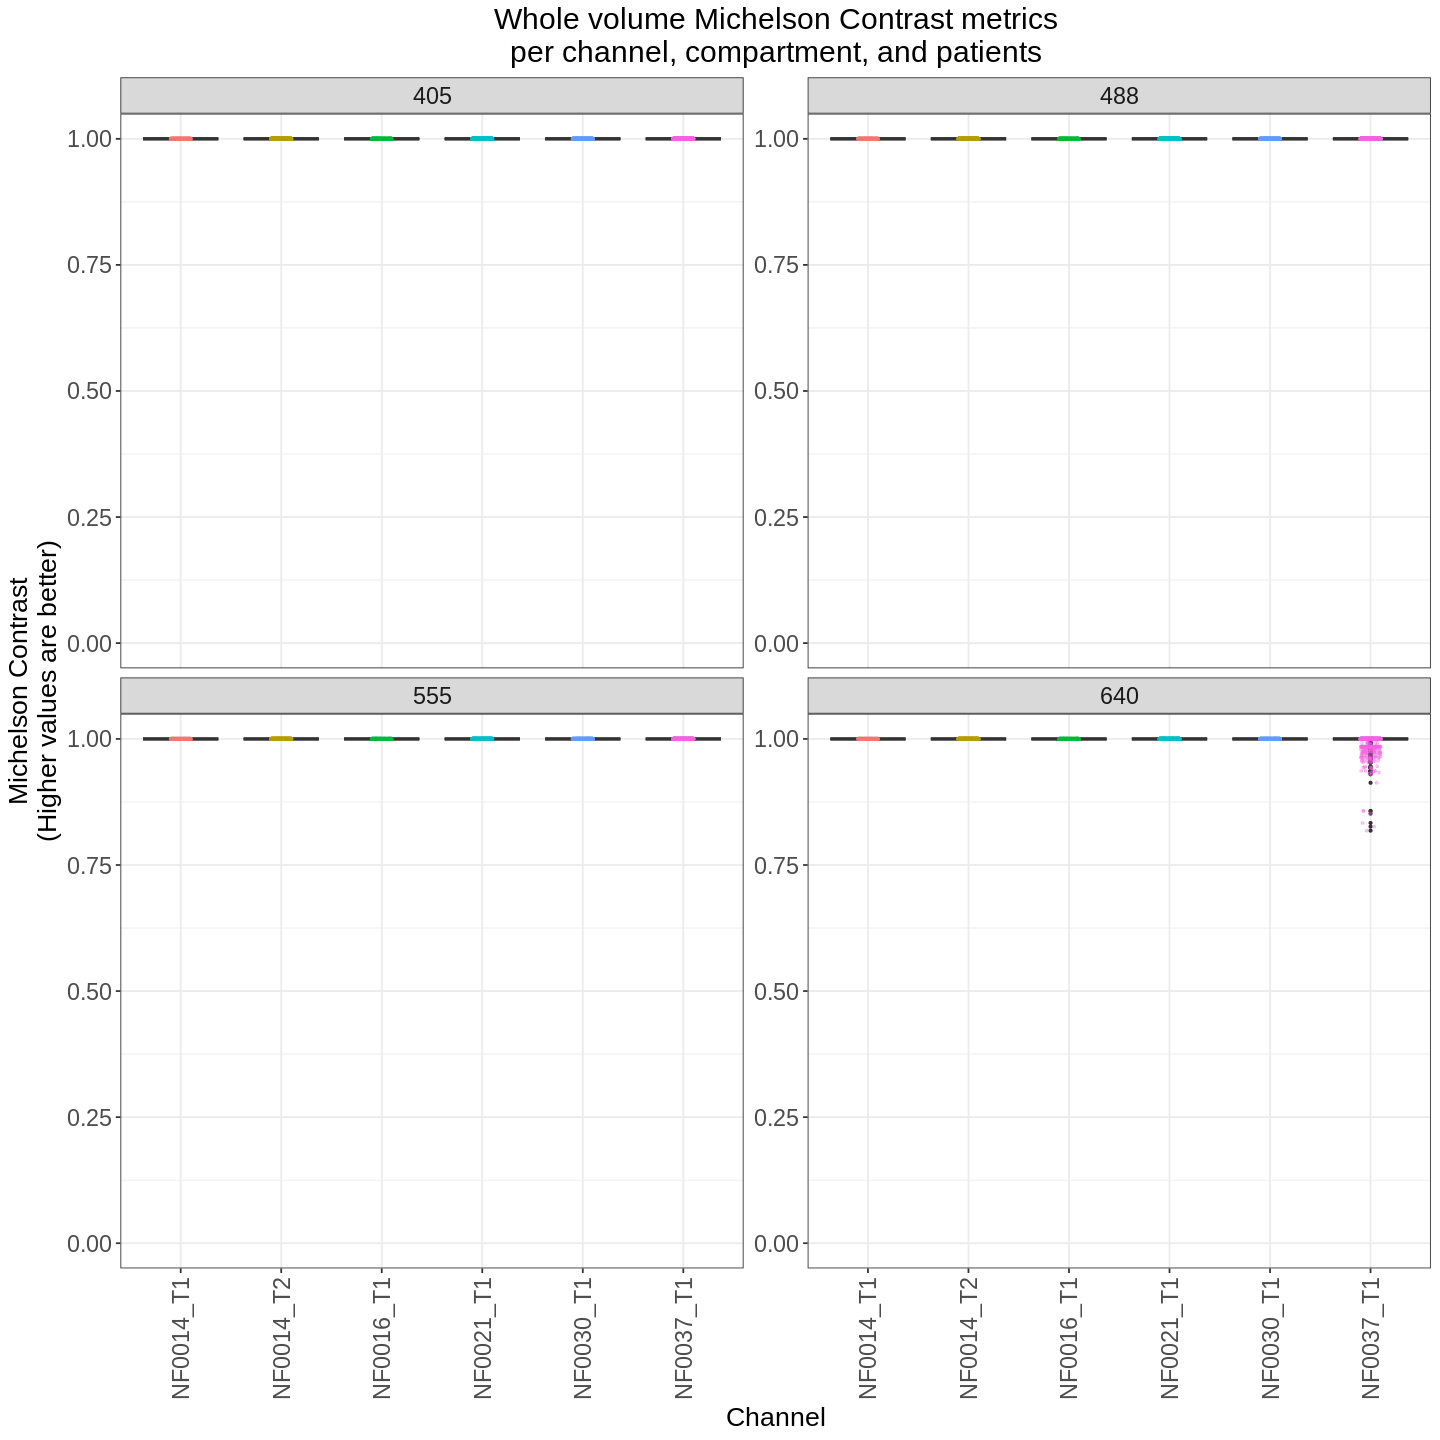

In [6]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
michelson_contrast_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = patient,
            y = michelson_contrast,
            fill = patient
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = patient
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )
    + labs(
        x = "Channel",
        y = "Michelson Contrast\n(Higher values are better)",
        title = "Whole volume Michelson Contrast metrics\nper channel, compartment, and patients"

    )
    + facet_wrap(channel~., scales = "free_y")

    + guides(
        fill = guide_legend(
            title = "Patient"
        ),
        color = "none"
    )
    + ylim(0,1)
    + plot_theme
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        legend.position = "none"
    )

)
ggsave(
    filename = file.path(
        figures_3D_path,
        "michelson_contrast_by_microscope_and_channel_3D.png"
    ),
    plot = michelson_contrast_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
michelson_contrast_plot


### RMS contrast

Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 236 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 236 rows containing missing values or values outside the scale range
(`geom_point()`).”


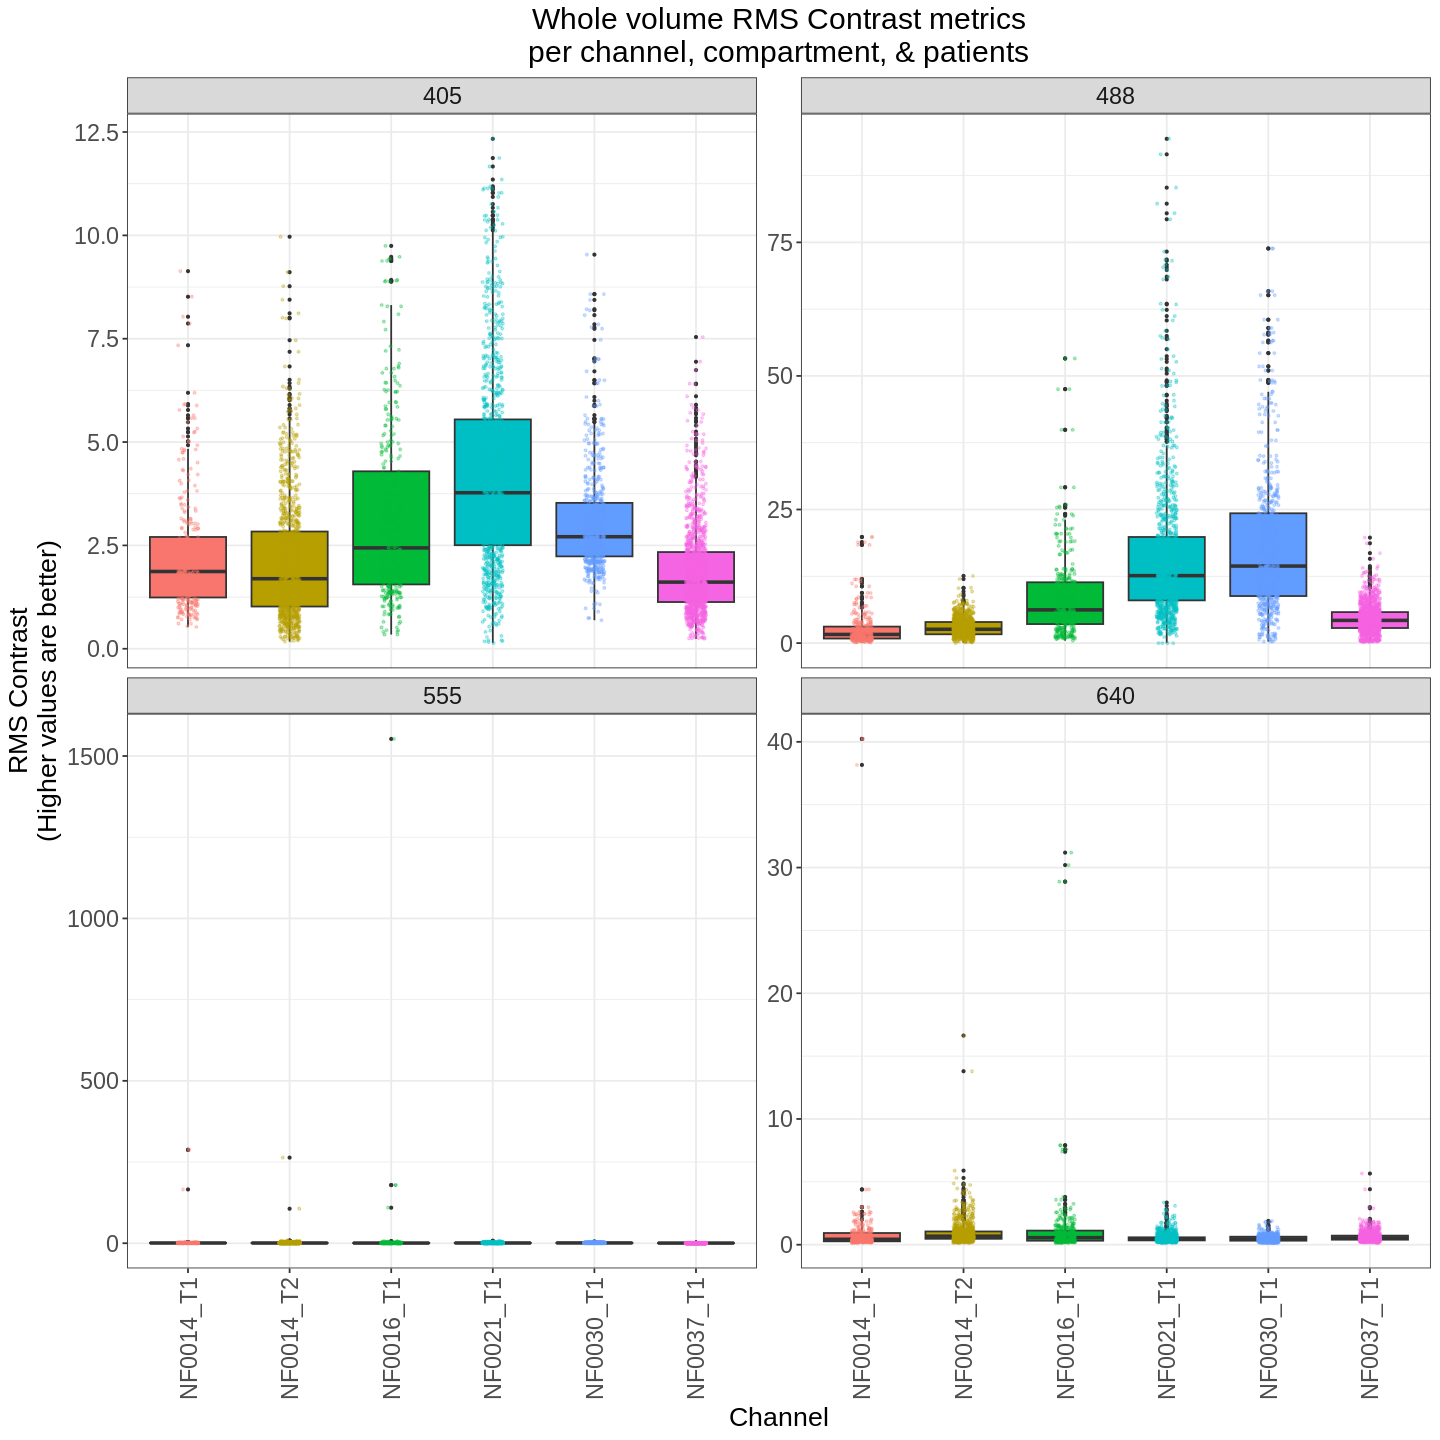

In [7]:
options(repr.plot.width = width_3D, repr.plot.height = height_3D)
RMS_contrast_plot <- (
    ggplot(
        data = raw_image_3D_quality_metrics,
        aes(
            x = patient,
            y = RMS_contrast,
            fill = patient
    )
    )
    + geom_boxplot(
        # add jitter and transparency to see all points
        outlier.size = 0.5,
        position = position_dodge(width = 0.75)
    )
    + geom_jitter(
        aes(
            color = patient
        ),
        position = position_jitterdodge(
            jitter.width = 0.2,
            dodge.width = 0.75
        ),
        alpha = 0.3,
        size = 0.5
    )

    + facet_wrap(channel~.,scales = "free_y")
    + labs(
        x = "Channel",
        y = "RMS Contrast\n(Higher values are better)",
        title = "Whole volume RMS Contrast metrics\nper channel, compartment, & patients"

    )
    + guides(
        fill = guide_legend(
            title = "Patient"
        ),
        color = "none"
    )
    + plot_theme
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        legend.position = "none"
    )
)
ggsave(
    filename = file.path(
        figures_3D_path,
        "RMS_contrast_by_microscope_and_channel_3D.png"
    ),
    plot = RMS_contrast_plot,
    width = width_3D,
    height = height_3D,
    units = "in",
    dpi = 600
)
RMS_contrast_plot


## 2D metrics

In [8]:
width_2D <- 12
height_2D <- 12
x_axis_label <- "Z-slice depth\n(Normalized per FOV to 0-1 scale)"

In [9]:

# normalize the per channel per microscope per well fov the z slice values
# to be between 0 and 1 for each channel and microscope combination
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    group_by(patient, channel, well_fov) %>%
    mutate(
        z_slice_normalized = (z_slice - min(z_slice)) / (max(z_slice) - min(z_slice))
    ) %>%
    ungroup()
# randomize the row order to avoid plotting one condition on top of the other
raw_image_2D_quality_metrics <- raw_image_2D_quality_metrics %>%
    group_by(patient) %>%
    sample_frac(1) %>%
    ungroup()
head(raw_image_2D_quality_metrics)


patient,well_fov,channel,z_slice,compartment,signal_to_noise_ratio,michelson_contrast,RMS_contrast,basicpy_status,well,WellRow,WellCol,well_position,treatment,dose,unit,z_slice_normalized
<chr>,<chr>,<chr>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<dbl>
NF0014_T1,E3-2,405,6,cell,16.088744,1,3.3142151,raw_image,E3,E,3,E3,Copanlisib,1,uM,0.2000000
NF0014_T1,D8-1,555,8,cell,8.755027,1,0.7890687,raw_image,D8,D,8,D8,Binimetinib,10,uM,0.2352941
NF0014_T1,C3-2,488,0,cell,5.859295,1,3.5582475,raw_image,C3,C,3,C3,Onalespib,1,uM,0.0000000
NF0014_T1,D7-1,488,44,cell,5.483662,1,1.4614307,raw_image,D7,D,7,D7,Cabozantinib,1,uM,0.9565217
NF0014_T1,D11-1,640,23,cell,10.838521,1,1.5564393,raw_image,D11,D,11,D11,Selumetinib,1,uM,0.4791667
NF0014_T1,D11-2,555,57,nuclei,2.979845,1,0.3006512,raw_image,D11,D,11,D11,Selumetinib,1,uM,0.9500000


### Signal to noise ratio

Warning message:
“Removed 72972 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 72972 rows containing missing values or values outside the scale range
(`geom_line()`).”


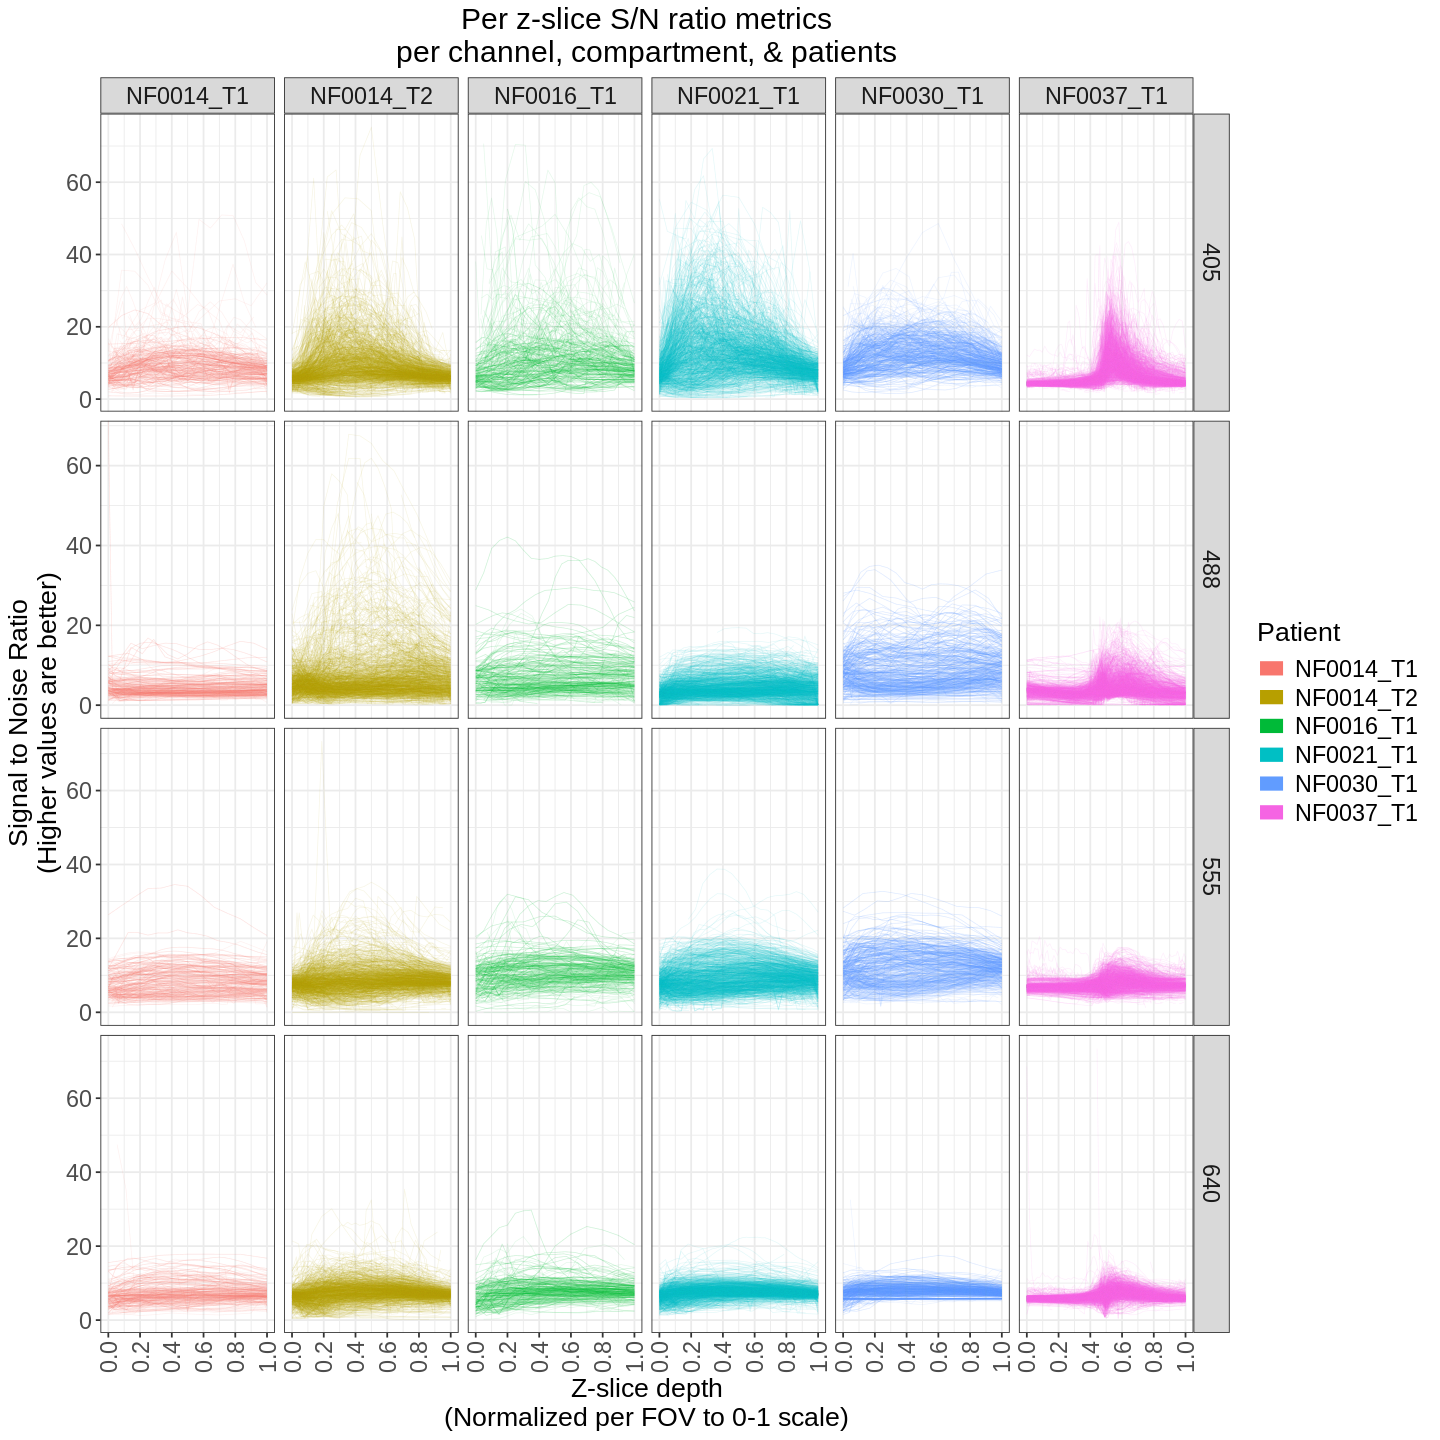

In [10]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
s_n_ratio_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = signal_to_noise_ratio,
            color = patient
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + labs(
        x = x_axis_label,
        y = "Signal to Noise Ratio\n(Higher values are better)",
        title = "Per z-slice S/N ratio metrics\nper channel, compartment, & patients"

    )
    + scale_x_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2), expand = expansion(mult = 0.05))
    + facet_grid(channel ~ patient, scales = "free")
    + guides(
        color = guide_legend(
            title = "Patient", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        ),
        text = element_text(size = 16)
    )
    + theme(
        axis.text = element_text(size = 14),
        axis.title = element_text(size = 16),
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 16),
        strip.text = element_text(size = 14)
    )
    + plot_theme
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    )
)
ggsave(
    filename = file.path(
        figures_2D_path,
        "signal_to_noise_ratio_by_microscope_and_channel_2D.png"
    ),
    plot = s_n_ratio_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
s_n_ratio_plot


### Michelson contrast

Warning message:
“Removed 73079 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 73079 rows containing missing values or values outside the scale range
(`geom_line()`).”


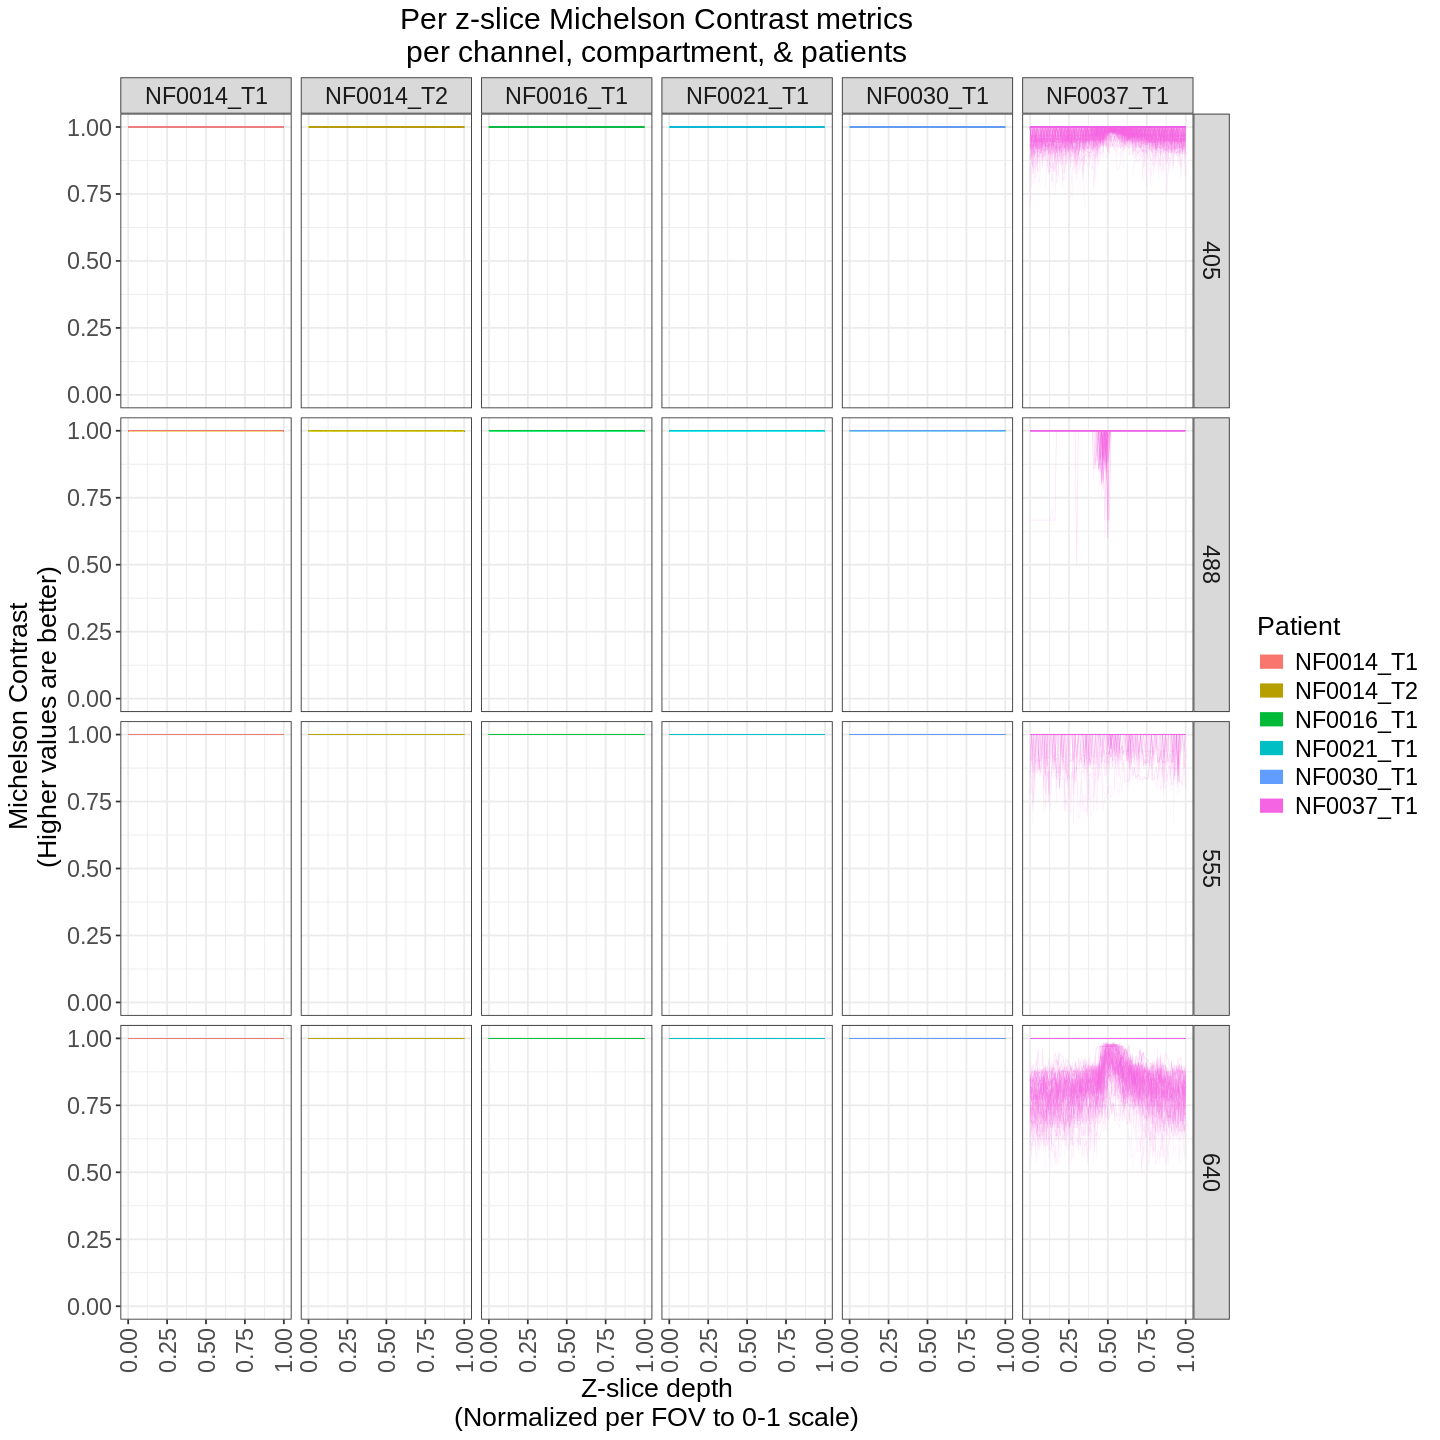

In [11]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
michelson_contrast_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = michelson_contrast,
            color = patient
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + labs(
        x = x_axis_label,
        y = "Michelson Contrast\n(Higher values are better)",
        title = "Per z-slice Michelson Contrast metrics\nper channel, compartment, & patients"
    )
    + ylim(0,1)
    + facet_grid(channel ~ patient, scales = "free")
    + guides(
        color = guide_legend(
            title = "Patient", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        )
    )
    + plot_theme
        + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    )

)
ggsave(
    filename = file.path(
        figures_2D_path,
        "michelson_contrast_by_microscope_and_channel_2D.png"
    ),
    plot = michelson_contrast_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
michelson_contrast_plot


### RMS contrast

Warning message:
“Removed 72972 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 72972 rows containing missing values or values outside the scale range
(`geom_line()`).”


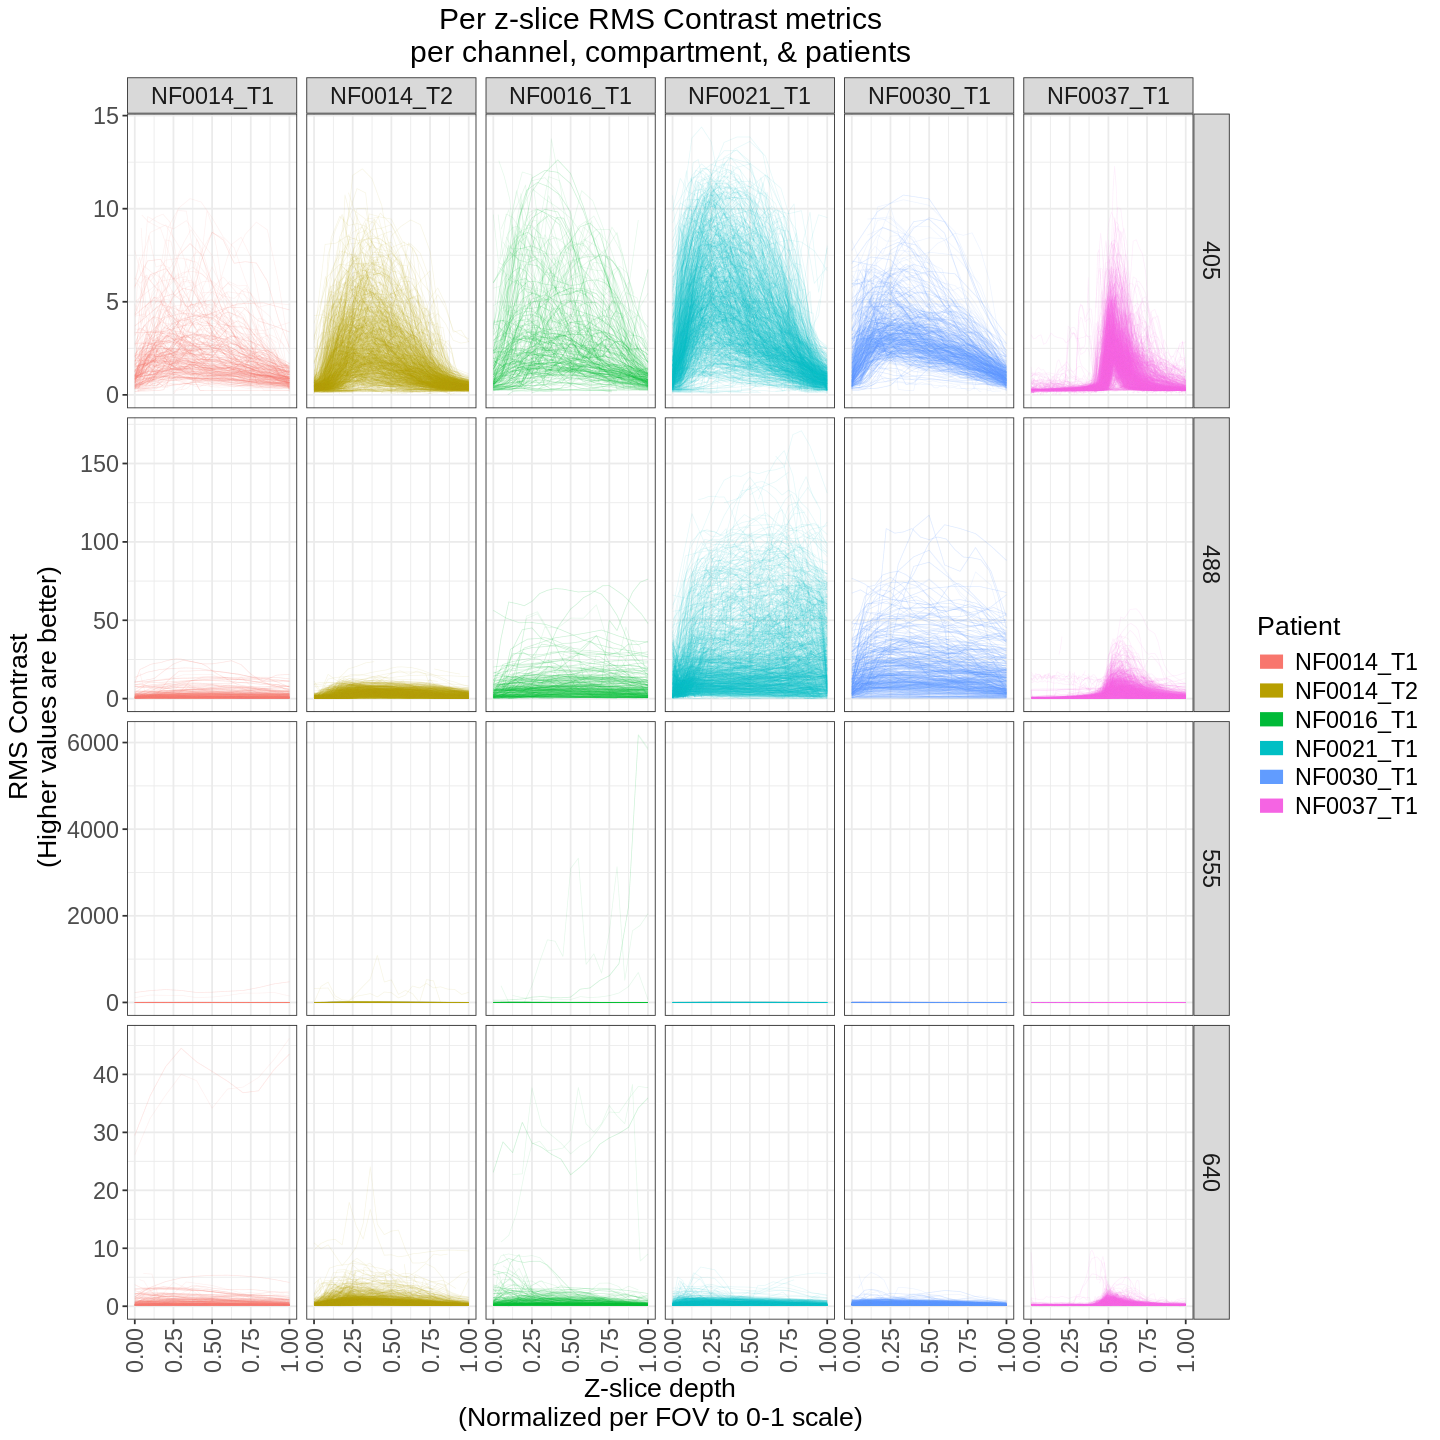

In [12]:
options(repr.plot.width = width_2D, repr.plot.height = height_2D)
RMS_contrast_plot <- (
    ggplot(
        data = raw_image_2D_quality_metrics,
        aes(
            x = z_slice_normalized,
            y = RMS_contrast,
            color = patient
    )
    )
    + geom_line(
        aes(group = interaction(well_fov, patient, channel,compartment)),
        alpha = 0.1,
        linewidth = 0.2
    )
    + labs(
        x = x_axis_label,
        y = "RMS Contrast\n(Higher values are better)",
        title = "Per z-slice RMS Contrast metrics\nper channel, compartment, & patients"
    )
    + facet_grid(channel ~ patient, scales = "free_y")
    + guides(
        color = guide_legend(
            title = "Patient", override.aes = list(
                linewidth = 4,
                alpha = 1
            )
        )
    )
    + plot_theme
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    )
)
ggsave(
    filename = file.path(
        figures_2D_path,
        "RMS_contrast_by_patient_and_channel_2D.png"
    ),
    plot = RMS_contrast_plot,
    width = width_2D,
    height = height_2D,
    units = "in",
    dpi = 600
)
RMS_contrast_plot